In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
# import pmdarima as pm

# Data Processing

In [2]:
df = pd.read_csv('./data/GlobalTemperatures.csv')

df['Time'] = pd.to_datetime(df['dt'])
df = df.set_index('Time')

df = pd.DataFrame(df['LandAverageTemperature'])
print(df.isnull().sum(), df.count())

LandAverageTemperature    12
dtype: int64 LandAverageTemperature    3180
dtype: int64


In [3]:
df['LandAverageTemperature'] = df['LandAverageTemperature'].fillna(df['LandAverageTemperature'].rolling(window=6, min_periods=1).mean())
print(df.isnull().sum())

LandAverageTemperature    0
dtype: int64


In [6]:
df.tail()

,LandAverageTemperature
Time,
2015-08-01,14.755
2015-09-01,12.999
2015-10-01,10.801
2015-11-01,7.433
2015-12-01,5.518


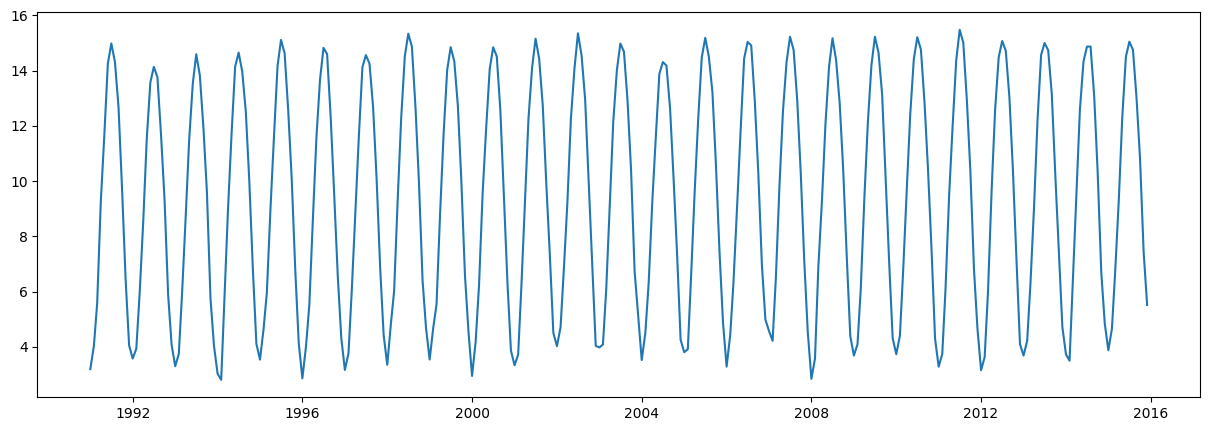

In [4]:
# Mostrando os últimos 300 registros.
plt.figure(figsize=(15, 5))
plt.plot(df[-300:])

In [5]:
decomposition = seasonal_decompose(x=df['LandAverageTemperature'], model='additive', period=12)
estimated_trend = decomposition.trend
estimated_seasonal = decomposition.seasonal
estimated_residual = decomposition.resid

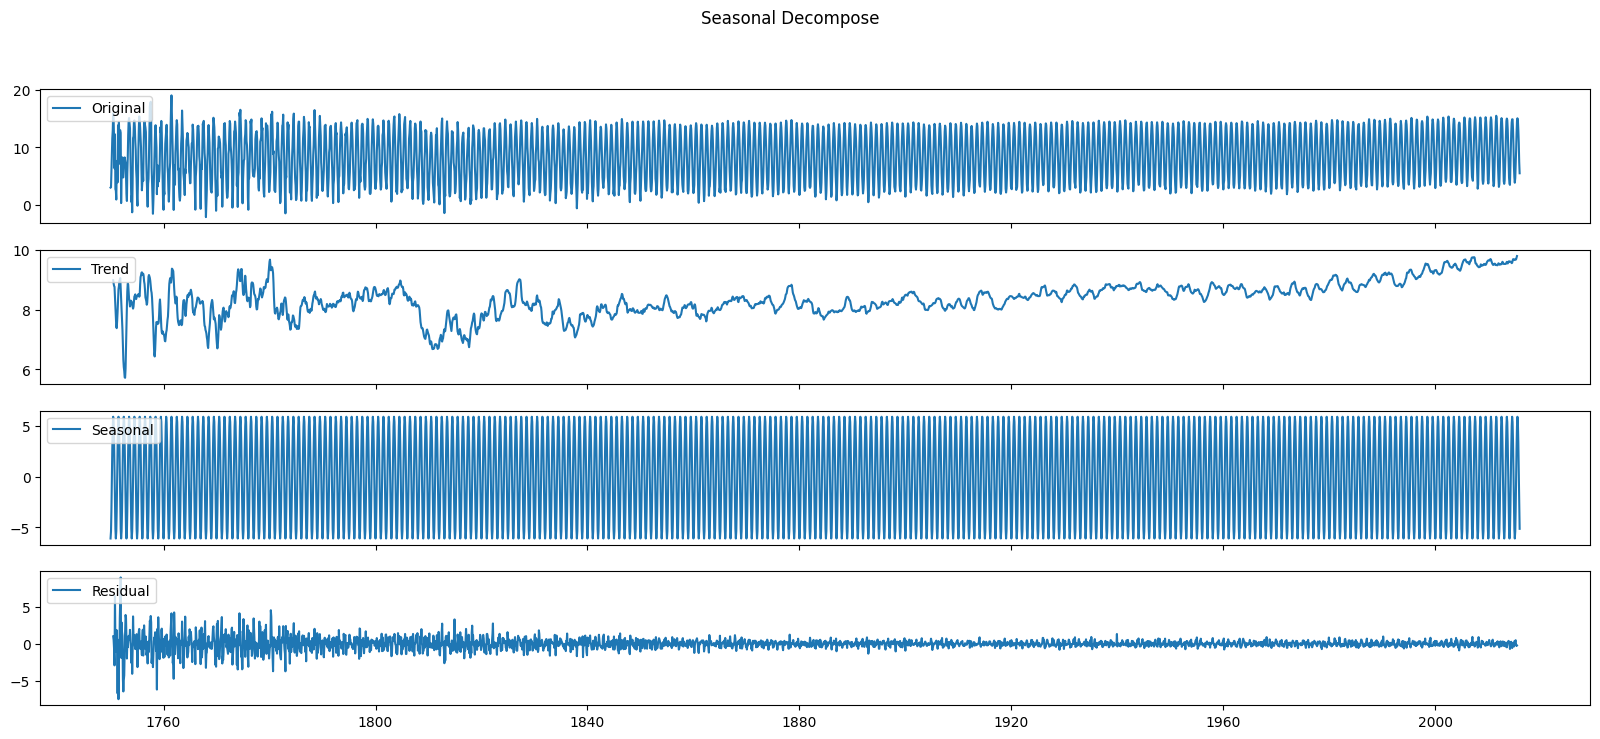

In [6]:
fig, axes = plt.subplots(4, 1, figsize=(20, 8), sharex=True)
fig.suptitle('Seasonal Decompose')

axes[0].plot(df, label='Original')
axes[0].legend(loc='upper left')
axes[1].plot(estimated_trend, label='Trend')
axes[1].legend(loc='upper left')
axes[2].plot(estimated_seasonal, label='Seasonal')
axes[2].legend(loc='upper left')
axes[3].plot(estimated_residual, label='Residual')
axes[3].legend(loc='upper left')

plt.show()

In [7]:
adf, p_value, usedlag, nobs, critical_values, icbest = adfuller(df)

print("ADF: ", adf)
print("P-Value: ", p_value)
print("Critical Values: ", critical_values)

ADF:  -4.2357288965335815
P-Value:  0.0005729134340901001
Critical Values:  {'1%': -3.4324197712239393, '5%': -2.862454498112156, '10%': -2.5672568084635663}


Segundo o teste de ADF (Augmented Dickey-Fuller), a série é estacionária (P-Value < 0.05) com 99% de confiabilidade.

In [8]:
chuncks = np.array_split(df['LandAverageTemperature'], indices_or_sections=100)
print('-'*30)
for i, chunck in enumerate(chuncks):
    print("{:5} | {:7.2f} | {:7.2f}".format(i, chunck.mean(), chunck.var()))

------------------------------
    0 |    8.03 |   19.52
    1 |    7.65 |   25.59
    2 |    9.40 |   29.26
    3 |    7.41 |   24.38
    4 |    7.69 |   27.34
    5 |    8.69 |   14.97
    6 |    7.97 |   25.25
    7 |    6.99 |   20.61
    8 |    8.68 |   22.09
    9 |    8.92 |   26.10
   10 |    7.96 |   14.50
   11 |    9.21 |   21.22
   12 |    8.01 |   28.14
   13 |    7.20 |   22.17
   14 |    8.75 |   22.17
   15 |    8.20 |   19.98
   16 |    7.88 |   16.58
   17 |    8.74 |   19.91
   18 |    8.69 |   21.08
   19 |    7.87 |   18.26
   20 |    9.21 |   22.72
   21 |    8.31 |   20.09
   22 |    6.43 |   19.32
   23 |    7.75 |   24.35
   24 |    7.50 |   18.86
   25 |    6.63 |   18.99
   26 |    8.24 |   17.49
   27 |    8.21 |   20.27
   28 |    7.98 |   15.48
   29 |    8.61 |   20.55
   30 |    8.10 |   18.01
   31 |    7.37 |   18.52
   32 |    7.87 |   17.99
   33 |    7.84 |   23.47
   34 |    7.27 |   18.06
   35 |    8.27 |   19.19
   36 |    8.39 |   19.86
   37 |

c:\Users\gusta\OneDrive\Área de Trabalho\Interface\myenv\Lib\site-packages\numpy\core\fromnumeric.py:57: FutureWarning: 'Series.swapaxes' is deprecated and will be removed in a future version. Please use 'Series.transpose' instead.
  return bound(*args, **kwds)


Logo, analisando as médias móveis e variâncias, é notável que o dataset possui média e variância constantes. De modo que, o modelo mais indicado será SARIMA, por conta da sazonalidade do dataset.

# Dividindo o Dataset

In [9]:
df_train = df['LandAverageTemperature'][:2226]
df_test = df['LandAverageTemperature'][2226:]

# Modelo SARIMA

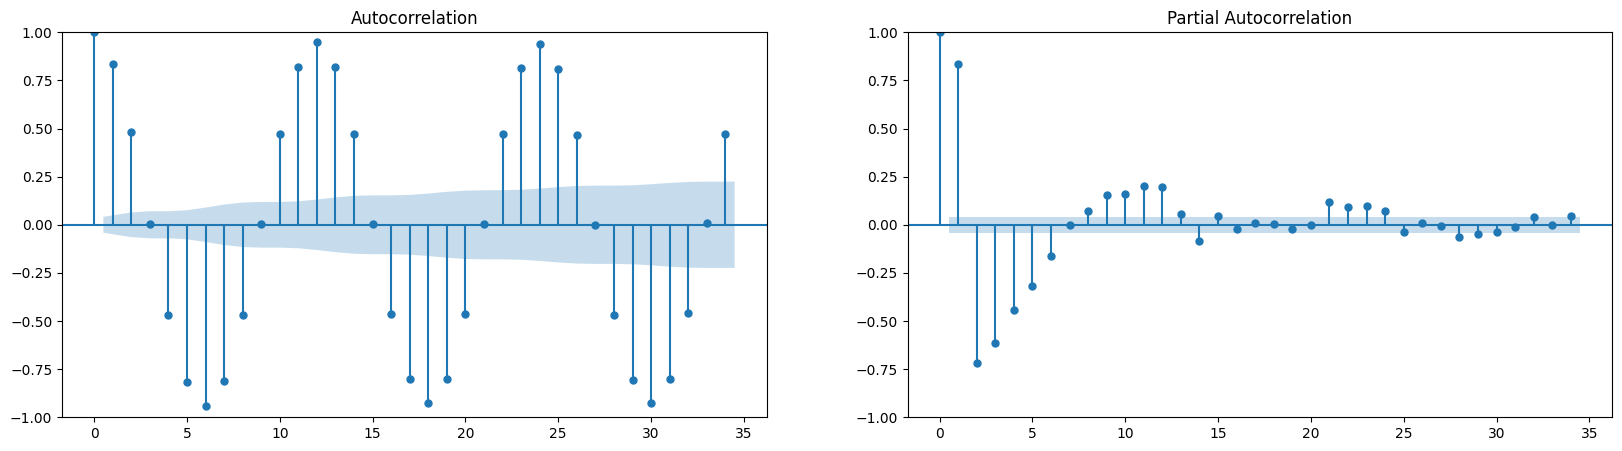

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(20, 5), sharex=False)
plot_acf(df_train, ax=axes[0])
plot_pacf(df_train, ax=axes[1])
plt.show()

Ajustar ainda mais os parâmetros abaixo. Consultar a documentação.

In [11]:
analysis = pm.auto_arima(df.LandAverageTemperature, start_p=2, d=0, start_q=0,
                      max_p=2, max_d=2, max_q=2, m=12,
                      start_P=2, D=1, start_Q=1, seasonal=True,
                      error_action="ignore", 
                      suppress_warnings=True,
                      stepwise=True, trace=True)

print(analysis.aic())

c:\Users\gusta\OneDrive\Área de Trabalho\Interface\myenv\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\gusta\OneDrive\Área de Trabalho\Interface\myenv\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Performing stepwise search to minimize aic
 ARIMA(2,0,0)(2,1,1)[12] intercept   : AIC=inf, Time=20.98 sec


c:\Users\gusta\OneDrive\Área de Trabalho\Interface\myenv\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=10033.880, Time=0.72 sec


c:\Users\gusta\OneDrive\Área de Trabalho\Interface\myenv\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

 ARIMA(1,0,2)(2,1,0)[12]             : AIC=8588.905, Time=7.57 sec


c:\Users\gusta\OneDrive\Área de Trabalho\Interface\myenv\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(2,0,1)(2,1,0)[12]             : AIC=8593.576, Time=9.38 sec


c:\Users\gusta\OneDrive\Área de Trabalho\Interface\myenv\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(1,0,1)(2,1,0)[12]             : AIC=8609.970, Time=7.05 sec

Best model:  ARIMA(2,0,2)(2,1,0)[12]          
Total fit time: 381.549 seconds
8569.077771574957


In [12]:
print(analysis.order, analysis.seasonal_order)

(2, 0, 2) (2, 1, 0, 12)


In [13]:
model = sm.tsa.statespace.SARIMAX(df,
                                order=(2, 0, 2),
                                seasonal_order=(2, 1, 0, 12),
                                trend='t').fit()
model.summary()

c:\Users\gusta\OneDrive\Área de Trabalho\Interface\myenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\gusta\OneDrive\Área de Trabalho\Interface\myenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\gusta\OneDrive\Área de Trabalho\Interface\myenv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:              LandAverageTemperature   No. Observations:                 3192
Model:             SARIMAX(2, 0, 2)x(2, 1, [], 12)   Log Likelihood               -4358.192
Date:                             Sun, 26 Jan 2025   AIC                           8732.385
Time:                                     15:58:48   BIC                           8780.902
Sample:                                 01-01-1750   HQIC                          8749.785
                                      - 12-01-2015                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
drift       3.445e-06   2.83e-05      0.122      0.903    -5.2e-05    5.89e-05
ar.L1          0.5425      0.110      4.922      0.000       0.326       0.758
ar.L2         -0.2046      0.071     -2.866      0.004      -0.345      -0.065
ma.L1         -0.2739      0.109     -2.518      0.012      -0.487      -0.061
ma.L2          0.2991      0.047      6.421      0.000       0.208       0.390
ar.S.L12      -0.5625      0.012    -48.365      0.000      -0.585      -0.540
ar.S.L24      -0.2820      0.011    -25.633      0.000      -0.304      -0.260
sigma2         1.1720      0.017     68.895      0.000       1.139       1.205
===================================================================================
Ljung-Box (L1) (Q):                   2.53   Jarque-Bera (JB):             14140.09
Prob(Q):                              0.11   Prob(JB):                         0.00
Heteroskedasticity (H):               0.05   Skew:                             0.16
Prob(H) (two-sided):                  0.00   Kurtosis:                        13.33
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [16]:
predicted = []
predicted = model.predict(start=2226, end=3200)  

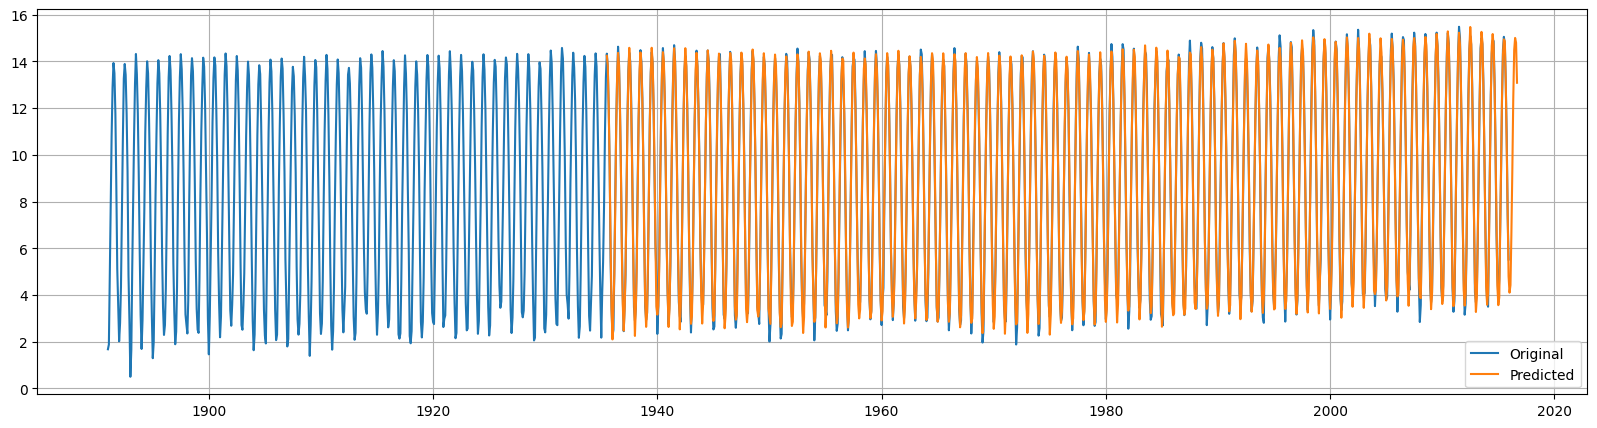

In [18]:
plt.figure(figsize=(20, 5))
plt.plot(df.index[-1500:], df['LandAverageTemperature'][-1500:], label='Original')
plt.plot(predicted.index, predicted, label='Predicted')
plt.legend()
plt.grid()
plt.show()

In [19]:
import pickle

with open('model_sarima.pkl', 'wb') as file:
    pickle.dump(model, file)